# Save a catalog of GeoTiffs as a multidimensional VRT for future use

Using USDA SOLUS Soil Properties Data: https://storage.googleapis.com/solus100pub/index.html

NOTE: this is a 'datacube' example, we're not concerned with mosaicing here because the Tiffs are national in extent and on the same grid alread! To create mosaics, see the [GDAL GTI driver](https://gdal.org/en/stable/drivers/raster/gti.html).

As with all datasets, there are quirks. These tiffs do not have TIFFTAG_SCALE information embedded in them, so `mask_and_scale=True` (real_value = pixel_value * scale + offset) doesn't work out of the box as you might expect. Instead you have to read the scale factor from the table above. But we can add/override that metadata in a VRT!

The basic approach is construct a well-formatted xr.Dataset with lazy metadata-only operations. Then serialize that to a multidimensional VRT with references to the original data. Think of it as a lightweight catalog.

## Get a catalog of GeoTiffs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import xgdal # our experimental backend
import pandas as pd
import os

In [3]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [4]:
# If using dask, best to use global env to avoid remote files not being found
os.environ['GS_NO_SIGN_REQUEST'] = 'YES'
os.environ['GDAL_DISABLE_READDIR_ON_OPEN'] = 'EMPTY_DIR'

In [5]:
BUCKET_URL = "https://storage.googleapis.com/solus100pub"
CSV_URL = f"{BUCKET_URL}/Final_Layer_Table_20231215.csv"

In [6]:
def load_layer_table(csv_url: str = CSV_URL) -> pd.DataFrame:
    """Download and return the SOLUS layer table as a DataFrame.

    Adds an ``href`` column with the full GCS URL for each COG.
    The CSV contains ``_2D_`` in a few filenames (e.g. ``anylithicdpt``)
    that do not match the actual bucket objects, so we strip that part.
    """
    df = pd.read_csv(csv_url, keep_default_na=False)
    df["filename"] = df["filename"].str.replace("_2D_", "_", regex=False)
    df["href"] = df["filename"].apply(lambda f: f"{BUCKET_URL}/{f}")
    return df

df = load_layer_table()

In [7]:
# For now let's just work with 'prediction' layers ('p.tif' files)
df = df[df["filename"].str.endswith("p.tif")]
# We'll also just start with a few properties
properties = ['anylithicdpt', 'cec7', 'claytotal', 'dbovendry', 'ph1to1h2o', 'sandtotal', 'silttotal']
df = df[df["property"].isin(properties)]
df.property.value_counts()

property
cec7            7
claytotal       7
dbovendry       7
ph1to1h2o       7
sandtotal       7
silttotal       7
anylithicdpt    1
Name: count, dtype: int64

In [8]:
df.head()

,filename,property,depth,filetype,scalar,description,units,href
2,anylithicdpt_cm_p.tif,anylithicdpt,NA,prediction,1,Depth to bedrock (lithic or paralithic),cm,https://storage.googleapis.com/solus100pub/any...
34,cec7_0_cm_p.tif,cec7,0_cm,prediction,10,Cation Exchange Capacity (pH 7),meq/100g,https://storage.googleapis.com/solus100pub/cec...
38,cec7_100_cm_p.tif,cec7,100_cm,prediction,10,Cation Exchange Capacity (pH 7),meq/100g,https://storage.googleapis.com/solus100pub/cec...
42,cec7_15_cm_p.tif,cec7,15_cm,prediction,10,Cation Exchange Capacity (pH 7),meq/100g,https://storage.googleapis.com/solus100pub/cec...
46,cec7_150_cm_p.tif,cec7,150_cm,prediction,10,Cation Exchange Capacity (pH 7),meq/100g,https://storage.googleapis.com/solus100pub/cec...


In [9]:
# Construct a multidimensional VRT from the catalog of GeoTiffs
def load_geotiff_layer(row: pd.Series, overview=None) -> xr.DataArray:
    """Load a single GeoTiff layer as an xarray DataArray."""
    # with xgdal.Env(GS_NO_SIGN_REQUEST=True, # GS_NO_SIGN_REQUEST=YES
    #            GDAL_DISABLE_READDIR_ON_OPEN='EMPTY_DIR'):
    if overview == -1 or overview is None:
        backend_kwargs = {}
    else:
        backend_kwargs = dict(overview_level=overview)

    da = xr.open_dataarray(row['href'],
                            engine='xgdal',
                            mask_and_scale=False,
                            chunks={}, # Need to use dask for lazy concatenation later
                            backend_kwargs=backend_kwargs
    )
    # NOTE: attributes may be lost in certain xarray operations
    # https://agdatacommons.nal.usda.gov/articles/dataset/Data_from_Soil_Landscapes_of_the_United_States_100-meter_SOLUS100_soil_property_maps_project_repository/25033856
    # The actual rasters must be divided by the scalars to get the actual units of the properties
    # unfortunately original tiffs don't have this in metadata!
    da.attrs['add_offset'] = 0
    da.attrs['scale_factor'] = 1/row['scalar']
    # Might as well put this all in...
    da.attrs['url'] = row['href']
    da.attrs['units'] = row['units']
    da.attrs['filetype'] = row['filetype']
    da.attrs['description'] = row['description']
    da.name = row['property']

    if row['depth'] != 'NA':
        da = da.rename({'band': 'depth'})
        da['depth'] = [int(row['depth'].rstrip('_cm'))]

    return da

# a layer for a specific depth
load_geotiff_layer(df.iloc[1], overview=2)

<xarray.DataArray 'cec7' (depth: 1, y: 3923, x: 6226)> Size: 49MB
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(1, 3923, 6226), dtype=uint16, chunksize=(1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * depth        (depth) int64 8B 0
  * y            (y) float64 31kB 3.258e+06 3.257e+06 ... 1.202e+05 1.194e+05
  * x            (x) float64 50kB -2.54e+06 -2.539e+06 ... 2.44e+06 2.441e+06
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y
Attributes:
    _FillValue:    65535.0
    add_offset:    0
    scale_factor:  0.1
    url:           https://storage.googleapis.com/solus100pub/cec7_0_cm_p.tif
    units:         meq/100g
    filetype:      prediction
    description:   Cation Exchange Capacity (pH 7)

In [10]:
# Layer w/o depth dimension
load_geotiff_layer(df.iloc[0], overview=2).squeeze()

<xarray.DataArray 'anylithicdpt' (y: 3923, x: 6226)> Size: 24MB
dask.array<getitem, shape=(3923, 6226), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 31kB dask.array<chunksize=(3923,), meta=np.ndarray>
  * x            (x) float64 50kB dask.array<chunksize=(6226,), meta=np.ndarray>
    band         int64 8B 1
  * spatial_ref  int64 8B 0
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y
Attributes:
    _FillValue:    255.0
    add_offset:    0
    scale_factor:  1.0
    url:           https://storage.googleapis.com/solus100pub/anylithicdpt_cm...
    units:         cm
    filetype:      prediction
    description:   Depth to bedrock (lithic or paralithic)

### NOTE: Currently the multidimensional VRT only works with full resolution datasets (not overviews)

In [11]:
# Let's try with another property
def construct_dataset(layer:str) -> xr.Dataset:
    df_i = df[df['property'] == layer]
    if len(df_i) > 1:
        data_arrays = [load_geotiff_layer(row, overview=-1) for _, row in df_i.iterrows()]
        # Ensure concat dimension is monotonically sorted
        # And only common attributs (e.g. not URL which differs by depth)
        ds = xr.concat(data_arrays,
                       dim='depth',
                       combine_attrs='drop_conflicts').sortby('depth').to_dataset()
    else:
        # No 'band' or 'depth' dimension for some static layers
        ds = load_geotiff_layer(df_i.iloc[0], overview=-1).squeeze(drop=True).to_dataset()
    return ds


#properties = ['anylithicdpt', 'cec7', 'claytotal', 'dbovendry', 'ph1to1h2o', 'sandtotal', 'silttotal']
construct_dataset('dbovendry')
#construct_dataset('anylithicdpt')

<xarray.Dataset> Size: 22GB
Dimensions:      (x: 49810, y: 31390, depth: 7)
Coordinates:
  * x            (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * y            (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * depth        (depth) int64 56B 0 5 15 30 60 100 150
  * spatial_ref  int64 8B 0
Data variables:
    dbovendry    (depth, y, x) uint16 22GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y

In [12]:
ds_dbovendry = construct_dataset('dbovendry')
ds_dbovendry

<xarray.Dataset> Size: 22GB
Dimensions:      (x: 49810, y: 31390, depth: 7)
Coordinates:
  * x            (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * y            (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * depth        (depth) int64 56B 0 5 15 30 60 100 150
  * spatial_ref  int64 8B 0
Data variables:
    dbovendry    (depth, y, x) uint16 22GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y

In [13]:
# Confirm plot covers full extent?
# Gotcha: will be surprisingly slow if chunks={} b/c dask is reading the whole array then subsetting.
#ds_dbovendry['dbovendry'].isel(depth=0, x=slice(0, 5000), y=slice(0, 4000)).compute().plot.imshow();

In [25]:
# We can open VRT XML strings directly without saving t disk!
#vrt_xml = ds_dbovendry.xgdal.to_mdim_vrt()

# or save to a local file:
vrt_xml = ds_dbovendry.xgdal.to_mdim_vrt('dbovendry_mdim.vrt')
print(vrt_xml)

<VRTDataset>
  <Group name="/">
    <Dimension name="depth" size="7"/>
    <Dimension name="y" size="31390" type="HORIZONTAL_Y" direction="NORTH"/>
    <Dimension name="x" size="49810" type="HORIZONTAL_X" direction="EAST"/>
    <Array name="depth">
      <DataType>Int64</DataType>
      <DimensionRef ref="depth"/>
      <InlineValues>0 5 15 30 60 100 150</InlineValues>
    </Array>
    <Array name="y">
      <DataType>Float64</DataType>
      <DimensionRef ref="y"/>
      <RegularlySpacedValues start="3257950.0" increment="-100.0"/>
    </Array>
    <Array name="x">
      <DataType>Float64</DataType>
      <DimensionRef ref="x"/>
      <RegularlySpacedValues start="-2539950.0" increment="100.0"/>
    </Array>
    <Array name="dbovendry">
      <DataType>UInt16</DataType>
      <DimensionRef ref="depth"/>
      <DimensionRef ref="y"/>
      <DimensionRef ref="x"/>
      <BlockSize>1,512,512</BlockSize>
      <SRS dataAxisToSRSAxisMapping="2,1">PROJCS["unknown",GEOGCS["NAD83",DATUM["Nort

In [28]:
# FAST! (no dask but GDAL does intelligent range requests)
# Also masked_and_scaled appropriately b/c we put that metadata in the VRT
ds = xr.open_dataset('dbovendry_mdim.vrt',
                     mask_and_scale=True,
                     # NOTE: dask needs a *file* not a XML string
                     # or else you get OSError: [Errno 63] File name too long: '<VRTDataset>\n
                     # chunks={},
                     engine='xgdal')
ds

<xarray.Dataset> Size: 88GB
Dimensions:      (depth: 7, y: 31390, x: 49810)
Coordinates:
  * depth        (depth) int64 56B 0 5 15 30 60 100 150
  * y            (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * x            (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * spatial_ref  int64 8B 0
Data variables:
    dbovendry    (depth, y, x) float64 88GB ...
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y

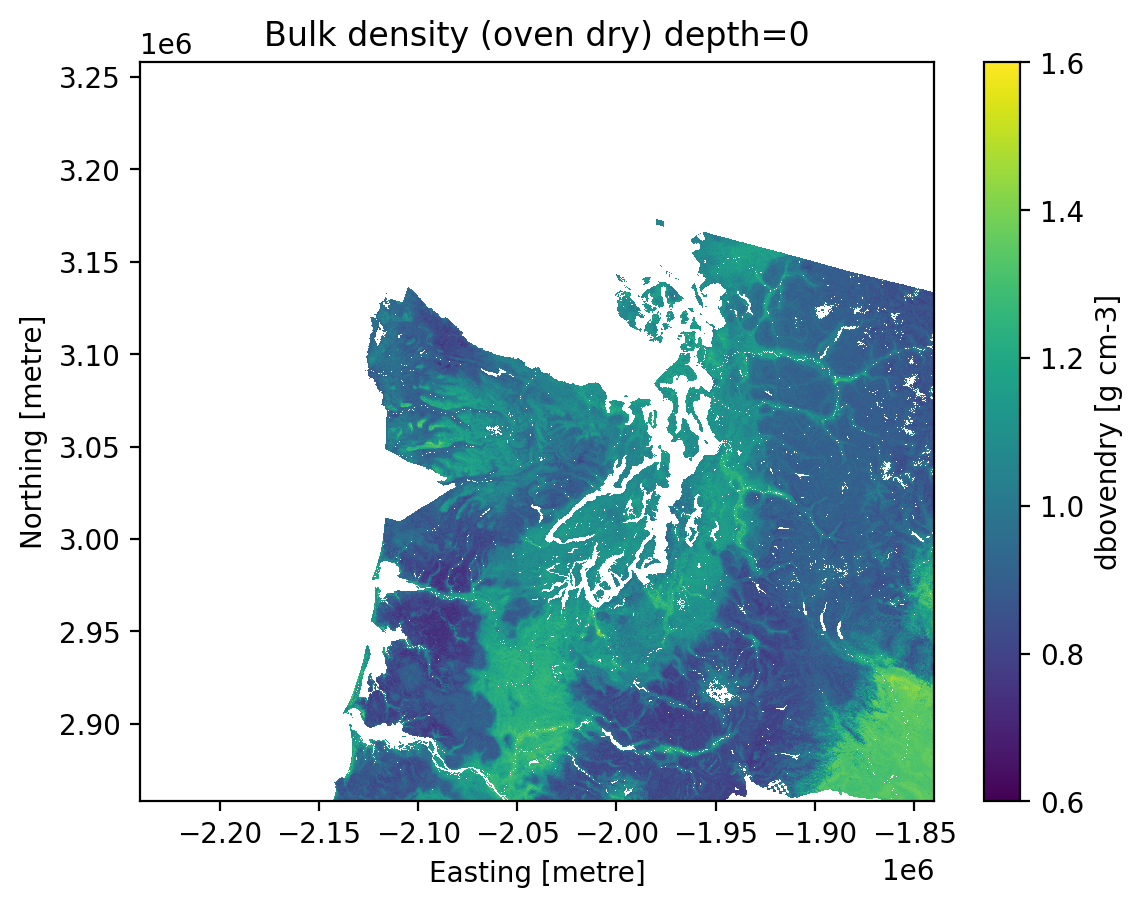

In [29]:
depth = 0
ds['dbovendry'].isel(depth=0, x=slice(3000, 7000), y=slice(0, 4000)).compute().plot.imshow()
plt.title(f"{ds['dbovendry'].attrs['description']} depth={depth}");

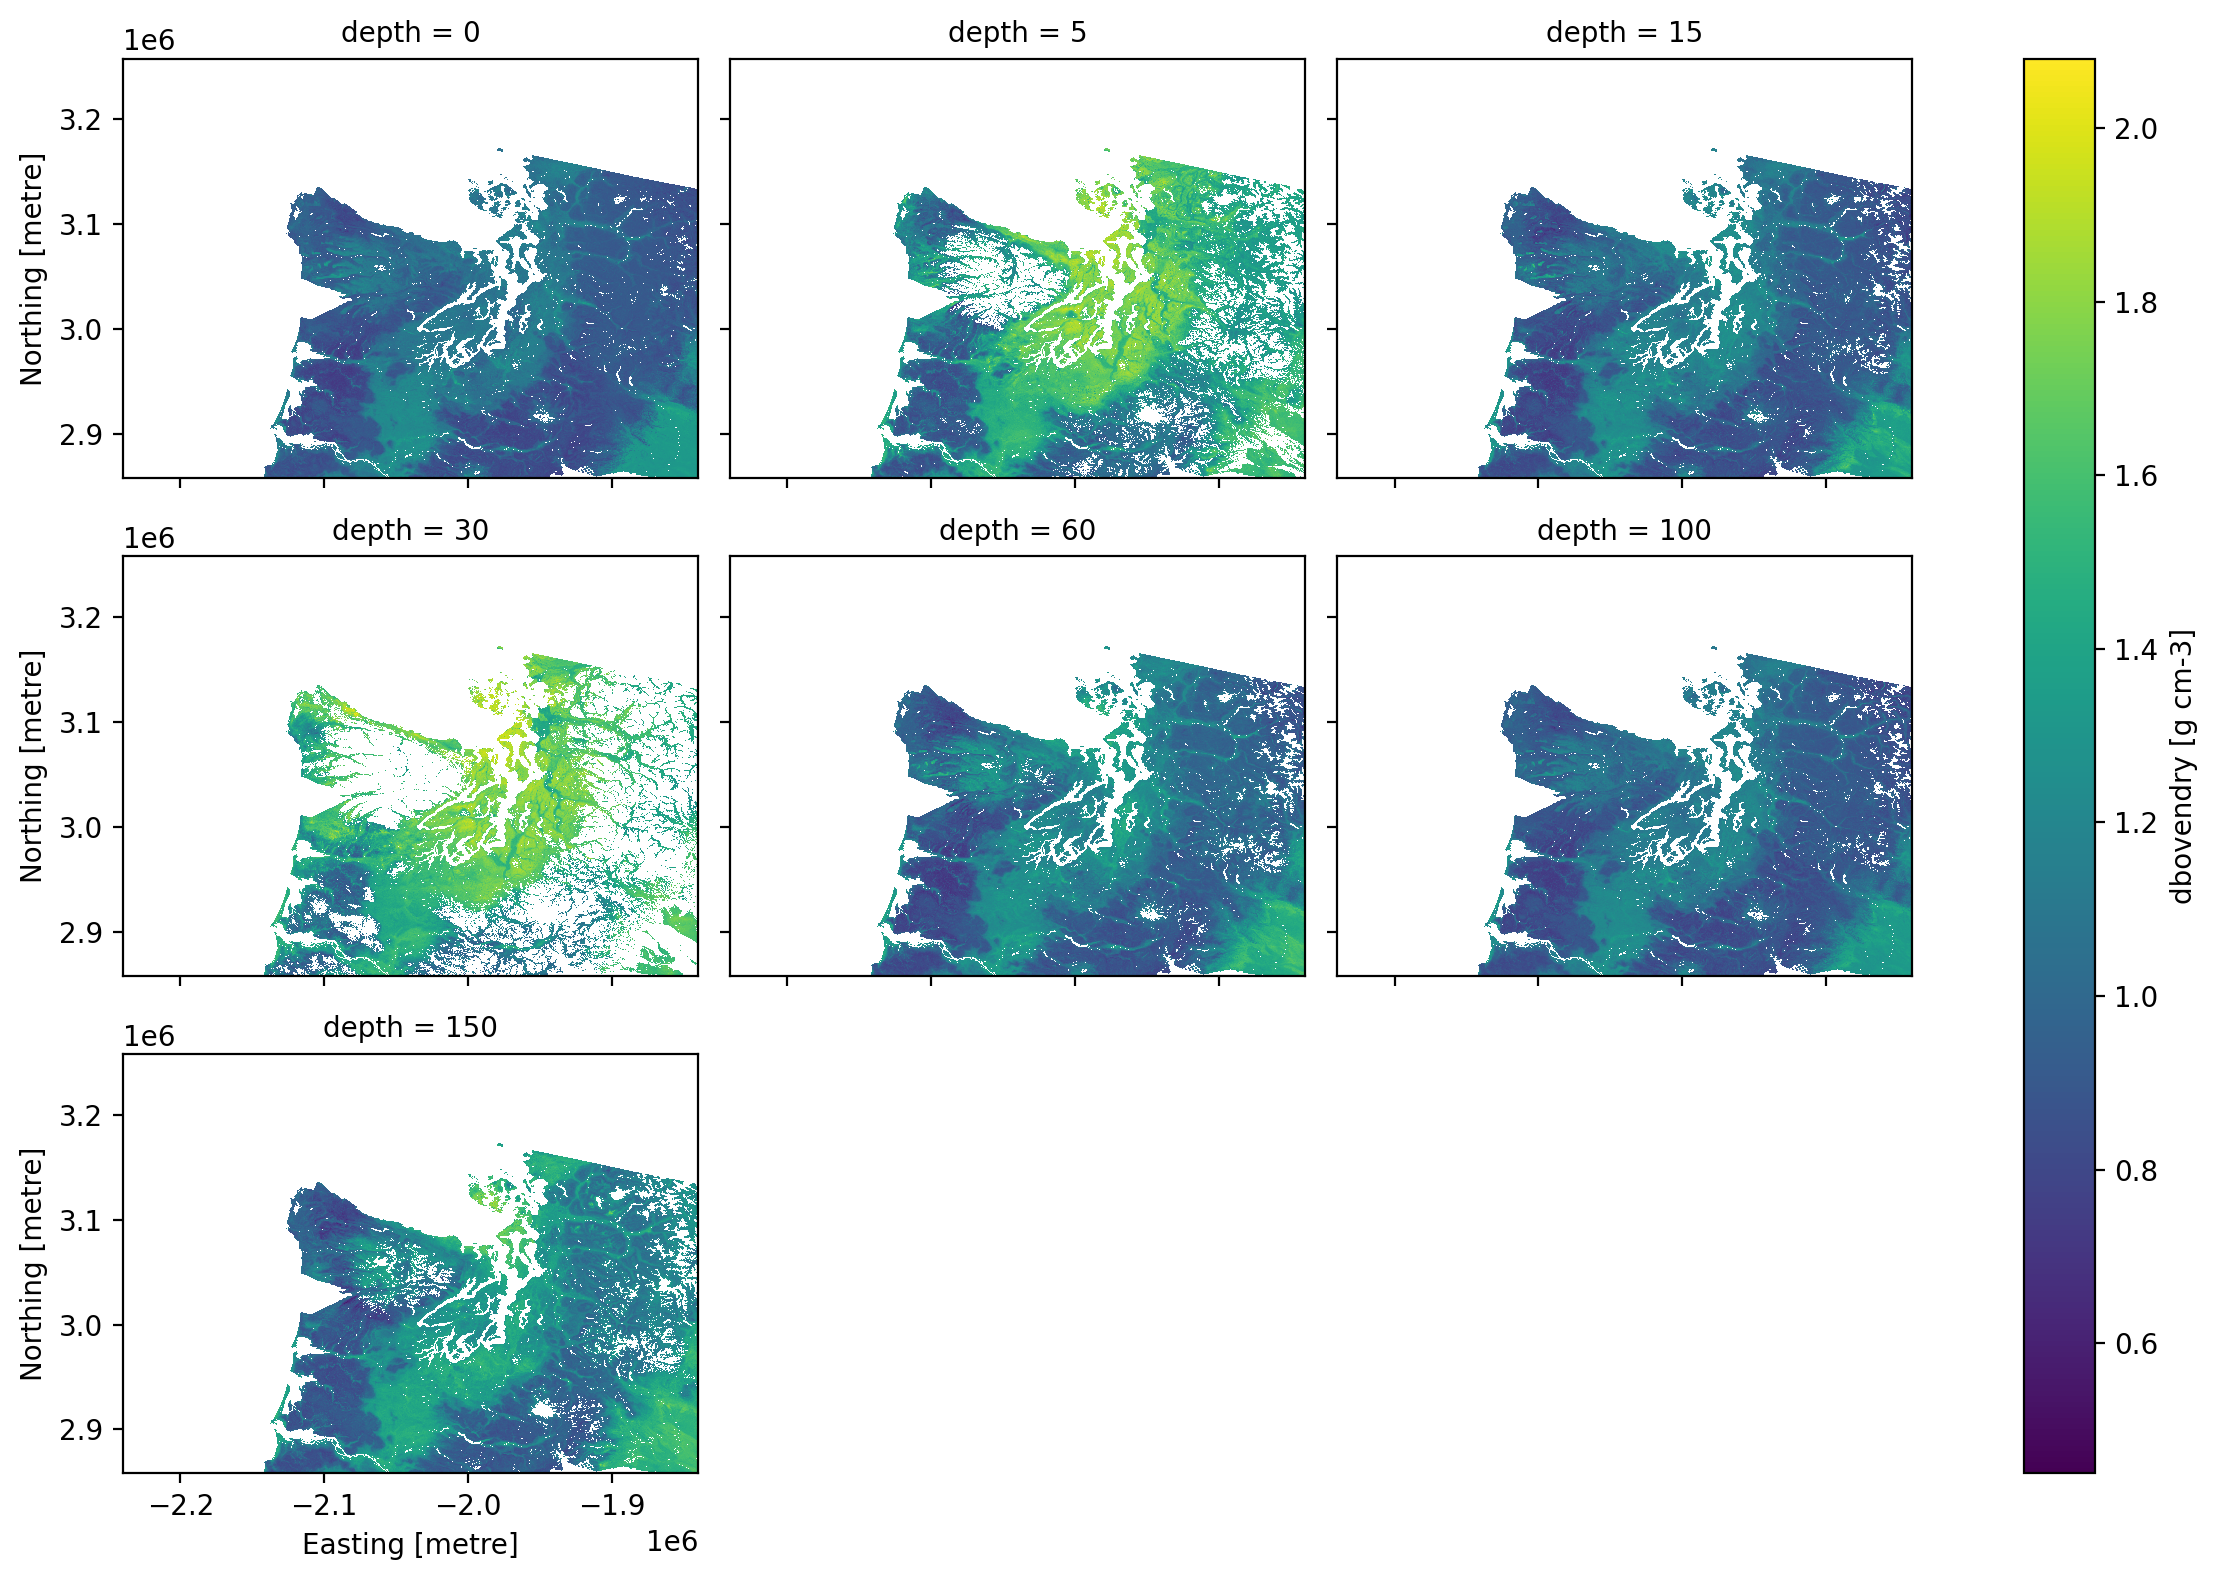

In [30]:
# Facet plot across depths
ds['dbovendry'].isel(x=slice(3000, 7000), y=slice(0, 4000)
                     ).compute().plot.imshow(col='depth',
                                             col_wrap=3,
                                             figsize=(12, 8));

In [31]:
#properties = ['anylithicdpt', 'cec7', 'claytotal', 'dbovendry', 'ph1to1h2o', 'sandtotal', 'silttotal']
datasets = []
for prop in properties:
    print(f"Loading property: {prop}")
    ds_i = construct_dataset(prop)
    datasets.append(ds_i)

DS = xr.merge(datasets)

Loading property: anylithicdpt
Loading property: cec7
Loading property: claytotal
Loading property: dbovendry
Loading property: ph1to1h2o
Loading property: sandtotal
Loading property: silttotal


In [32]:
DS

<xarray.Dataset> Size: 100GB
Dimensions:       (x: 49810, y: 31390, depth: 7)
Coordinates:
  * x             (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * y             (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * depth         (depth) int64 56B 0 5 15 30 60 100 150
  * spatial_ref   int64 8B 0
Data variables:
    anylithicdpt  (y, x) uint8 2GB dask.array<chunksize=(512, 512), meta=np.ndarray>
    cec7          (depth, y, x) uint16 22GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    claytotal     (depth, y, x) uint8 11GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    dbovendry     (depth, y, x) uint16 22GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    ph1to1h2o     (depth, y, x) uint16 22GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    sandtotal     (depth, y, x) uint8 11GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    silttotal     (depth, y, x) uint8 11GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y

In [36]:
# Returns a string and also writes to disk
merged_vrt = DS.xgdal.to_mdim_vrt('combined_mdim.vrt')
ds_mdim = xr.open_dataset(merged_vrt,
                          mask_and_scale=True,
                          engine='xgdal')
ds_mdim

<xarray.Dataset> Size: 400GB
Dimensions:       (y: 31390, x: 49810, depth: 7)
Coordinates:
  * y             (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * x             (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * depth         (depth) int64 56B 0 5 15 30 60 100 150
  * spatial_ref   int64 8B 0
Data variables:
    anylithicdpt  (y, x) float32 6GB ...
    cec7          (depth, y, x) float64 88GB ...
    claytotal     (depth, y, x) float32 44GB ...
    dbovendry     (depth, y, x) float64 88GB ...
    ph1to1h2o     (depth, y, x) float64 88GB ...
    sandtotal     (depth, y, x) float32 44GB ...
    silttotal     (depth, y, x) float32 44GB ...
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y

In [35]:
with xr.set_options(display_style="text"):
    print(ds_mdim)

<xarray.Dataset> Size: 400GB
Dimensions:       (y: 31390, x: 49810, depth: 7)
Coordinates:
  * y             (y) float64 251kB 3.258e+06 3.258e+06 ... 1.192e+05 1.19e+05
  * x             (x) float64 398kB -2.54e+06 -2.54e+06 ... 2.441e+06 2.441e+06
  * depth         (depth) int64 56B 0 5 15 30 60 100 150
  * spatial_ref   int64 8B 0
Data variables:
    anylithicdpt  (y, x) float32 6GB ...
    cec7          (depth, y, x) float64 88GB ...
    claytotal     (depth, y, x) float32 44GB ...
    dbovendry     (depth, y, x) float64 88GB ...
    ph1to1h2o     (depth, y, x) float64 88GB ...
    sandtotal     (depth, y, x) float32 44GB ...
    silttotal     (depth, y, x) float32 44GB ...
Indexes:
    spatial_ref  CRSIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  ┌ x            RasterIndex (crs=PROJCS["unknown",GEOGCS["NAD83",DATUM["North_American_Datum_198 ...)
  └ y


#### TODO:
- Test various xarray operations 
- Experiment with datatree 
- VRT with multiple groups